# Investigating a single neuron

In this task you can familiarise yourself with the way you will interact with the BrainScaleS-2 chip during the lab exercises.
For all tasks there exist jupyter notebooks that are intended to be used as a basis for the results.
If you are not familiar with python or jupyter notebooks before beginning this lab course, we recommend that you spend some time beforehand to familiarise yourself.

During the execution of some of the notebook cells, you will cause an experiment to be run on a BrainScaleS-2 system remotely.
You will find that due to the analog nature of some of the system’s implementation the execution is not deterministic, i.e., not each hardware execution will result in the same outcome.

Generally speaking the simplest hardware experiment can be divided in three steps

- hardware configuration  
- hardware execution  
- analysis of hardware observables.  


More sophisticated experiments can involve multiple iterations of these basic three steps or a subset of them.
At the level of abstraction you will be working on for these lab exercises, most of the intricacies of the hardware configuration and execution will be hidden behind a common high-level [API](fortgeschrittenen_praktikum.ipynb#term-API), called PyNN.

In the next section we will set up a connection to an RPC server that multiplexes connections to the hardware, which will allow us to work with the system interactively.
This process is handled by a custom microscheduler (*quiggeldy*), a conceptual view of which you can see in the following figure.
The actual hardware execution time has been colored in blue.

<img src="static/daas_multi.png" style="width:65%;" align="center">

At the end of this notebook you will find a number of exercises to complete.

## Experiment setup

To prepare for the execution of experiments on the neuromorphic system, you have to first connect to the scheduling server as follows.
You will need to run this cell once after starting or resetting the Jupyter backend.
The easiest way to escape from a broken state, will be to select “Kernel -> Restart” in the menu above and reexecute the following cell.

In [1]:
from _static.common.helpers import setup_hardware_client
setup_hardware_client()

INFO  15:52:30,571  demo_helpers Connection to hxcube7fpga0chip57_1 established


A default calibration is generated for every setup every night.
We save the nightly calibration in a variable such that we can use it later when we define our experiment.

In [2]:
from _static.common.helpers import get_nightly_calibration
calib = get_nightly_calibration()

We store results for documentation and to perform evaluations in a common
place for each of the tasks.

In [3]:
import pathlib
results_folder = pathlib.Path('results/task1')
results_folder.mkdir(parents=True, exist_ok=True)

We start by importing the relevant python packages we need for our experiment and setting up the enviroment for experiment execution.

In [4]:
import pynn_brainscales.brainscales2 as pynn

from pynn_brainscales.brainscales2 import Population
from pynn_brainscales.brainscales2.standardmodels.cells import SpikeSourceArray
from pynn_brainscales.brainscales2.standardmodels.synapses import StaticSynapse

The following function allows us to quickly plot the membrane trace and spikes of a neuron.

In [5]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import time

plt.style.use("_static/matplotlibrc")

def plot_membrane_dynamics(population: Population, segment_id=-1, ylim=None):
    """
    Plot the membrane potential of the neuron in a given population view. Only
    population views of size 1 are supported.
    :param population: Population, membrane traces and spikes are plotted for.
    :param segment_id: Index of the neo segment to be plotted. Defaults to
                       -1, encoding the last recorded segment.
    :param ylim: y-axis limits for the plot.
    """
    if len(population) != 1:
        raise ValueError("Plotting is supported for populations of size 1.")
    # Experimental results are given in the 'neo' data format
    mem_v = population.get_data("v").segments[segment_id].irregularlysampledsignals[0]
    spikes = population.get_data("spikes").segments[-1].spiketrains[0]

    plt.plot(mem_v.times, mem_v, alpha=0.5, color='black')

    # indicate the spikes as red dots
    plt.scatter(spikes, np.max(mem_v)*np.ones_like(spikes), color='red')
    plt.xlabel("Wall clock time [ms]")
    plt.ylabel("ADC readout [a.u.]")
    if ylim:
        plt.ylim(ylim)

For our first experiment, we create a single neuron and record its spikes as well as its membrane potential.

In [6]:
def experiment(
        title,
        v_leak,
        v_threshold,
        v_reset,
        i_bias_leak,
        current_enable = False,
        current = 0,    # range: 0-1022
        savefig = False,
        plotfig = True
    ):
    """
    Set up a leak over threshold neuron.

    :param v_leak: Leak potential.
    :param v_threshold: Spike threshold potential.
    :param v_reset: Reset potential.
    :param i_bias_leak: Controls the leak conductance (membrane time constant).
    :param savefig: Save the experiment figure.
    """

    # everything between pynn.setup() and pynn.end()
    # below is part of one hardware run.
    pynn.setup()

    # a pynn.Population corresponds to a certain number of
    # neuron circuits on the chip
    pop = pynn.Population(
            1,
            pynn.cells.HXNeuron(
                # Leak potential, range: 400-1000
                leak_v_leak = v_leak,
                # Leak conductance, range: 0-1022
                leak_i_bias = i_bias_leak,
                # Threshold potential, range: 0-500
                threshold_v_threshold = v_threshold,
                # Reset potential, range: 300-1000
                reset_v_reset = v_reset,
                # Membrane capacitance, range: 0-63
                membrane_capacitance_capacitance = 63,
                # Refractory time (counter), range: 0-255
                refractory_period_refractory_time = 255,
                # Enable reset on threshold crossing
                threshold_enable = True,
                # Reset conductance, range: 0-1022
                reset_i_bias = 1022,
                # Increase reset conductance
                reset_enable_multiplication = True,
                # Choose to have constant current offset
                constant_current_enable = current_enable,
                # Add constant current offset
                constant_current_i_offset = current
            )
    )

    pop.record(["v", "spikes"])

    # this triggers a hardware execution
    # with a duration of 0.2 ms
    pynn.run(0.2)

    if plotfig:
        plt.figure()
        plt.title(title)
        plot_membrane_dynamics(pop, ylim=(100, 800))
        if savefig:
            plt.savefig(results_folder.joinpath(f'fp_task1_{time.strftime("%Y%m%d-%H%M%S")}.png'))
        plt.show()

    mem = pop.get_data("v").segments[-1].irregularlysampledsignals[0]
    spikes = pop.get_data("spikes").segments[-1].spiketrains[0]
    pynn.end()

    return mem, spikes

In [7]:
from ipywidgets import interact, IntSlider, FloatSlider
from functools import partial
IntSlider = partial(IntSlider, continuous_update=False)

interact(
    experiment,
    title="Task 1: Leak over threshold",
    v_leak=IntSlider(min=400, max=1022, step=1, value=1000),
    v_threshold=IntSlider(min=0, max=500, step=1, value=500),
    v_reset=IntSlider(min=300, max=1022, step=1, value=400),
    i_bias_leak=IntSlider(min=0, max=1022, step=1, value=150),
)

interactive(children=(Text(value='Task 1: Leak over threshold', description='title'), IntSlider(value=1000, co…

<function __main__.experiment(title, v_leak, v_threshold, v_reset, i_bias_leak, current_enable=False, current=0, savefig=False, plotfig=True)>

## Exercises

### A continuously spiking neuron

As a first exercise, set the neuron up such that it spikes continuously without any external input.
For that purpose, play with the function’s parameters and note down a suitable configuration in the following cell.
Make sure to also save the resulting plot.

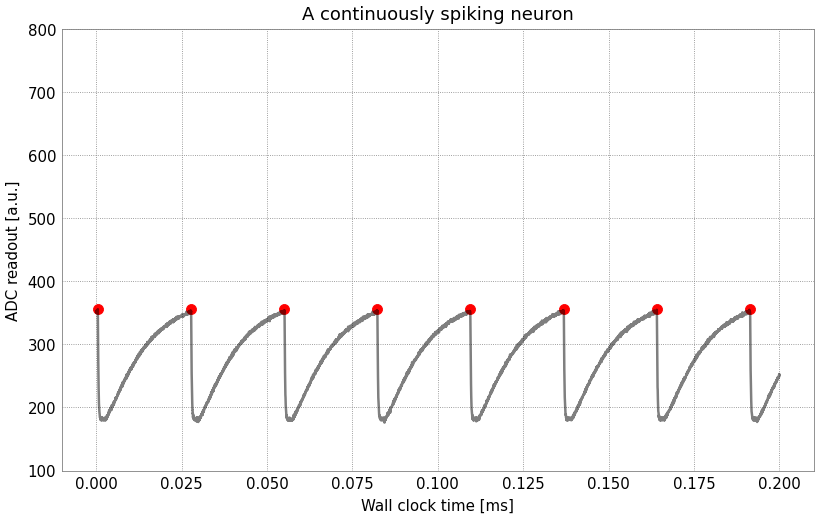

In [8]:
mem, spikes = experiment(
    title="A continuously spiking neuron",
    v_leak = 580,
    v_threshold = 220,
    v_reset = 370,
    i_bias_leak = 100,
    savefig = True
)

### Simple spike train statistics

- Calculate the neuron’s average firing rate.  
- Derive the inter-spike intervals (ISIs) of the spike train recorded in the previous exercise.
  The inter-spike interval denotes the time between two consecutive spikes of a neuron.
  Plot a histogram of the ISIs.  
- Identify a method to calculate the mean and standard deviation of the neuron’s instantaneous firing rate.
  The instantaneous firing rate provides a moment-by-moment measure of the neuron’s activity.  


Hint: You may use, e.g., [np.diff](https://numpy.org/doc/stable/reference/generated/numpy.diff.html), [np.mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html), and [np.std](https://numpy.org/doc/stable/reference/generated/numpy.std.html) to complete these tasks.

In [9]:
def calculate_frequency(spikes):
    distances = np.array([spikes[i+1] - spikes[i] for i, spike in enumerate(spikes[:-1])])
    frequencies = 1 / distances
    frequency = np.mean(frequencies)
    frequency_error = np.std(frequencies)
    return frequency, frequency_error

mem, spikes = experiment(
    title="A continuously spiking neuron",
    v_leak = 580,
    v_threshold = 220,
    v_reset = 370,
    i_bias_leak = 100,
    savefig = False,
    plotfig = False
)

frequency, frequency_error = calculate_frequency(spikes)

print(f'Average firing rate (frequency of neuron spiking):    {frequency} ± {frequency_error}')

Average firing rate (frequency of neuron spiking):    36.827807933475846 ± 0.3184056115875652


### Recording the f-I curve of a silicon neuron

Next, we want to study the behavior of a single neuron stimulated with a current source.
For this, we introduce a new parameter for our neuron model.
This will allow to enable/disable a constant current source and observe the impact.

- Add constant_current_enable (True/False) and constant_current_i_offset (range=0-1022) as parameters into your experiment  
- Configure a non firing neuron  
- Vary the current and observe the impact  

In [10]:
# interactive model for changing the current
interact(
    experiment,
    title = "Task 2: Current introduced firing",
    v_leak = IntSlider(min = 400, max = 1022, step = 1, value = 1000),
    v_threshold = IntSlider(min = 0, max = 500, step = 1, value = 500),
    v_reset = IntSlider(min = 300, max = 1022, step = 1, value = 400),
    i_bias_leak = IntSlider(min = 0, max = 1022, step = 1, value = 150),
    current_enable = False,
    current = IntSlider(min = 0, max = 1022, step = 1, value = 300),
    savefig = False,
    plotfig = True
);

interactive(children=(Text(value='Task 2: Current introduced firing', description='title'), IntSlider(value=10…

- To quantify your observations write a program that sweeps over a current range from 0 up to 800.  
- Plot the neuron’s mean instantaneous firing rate including its error over current.  

In [11]:
n_measurements = 50
measurement_currents = np.linspace(0, 800, n_measurements)
measurement_frequencies = np.array([np.nan]*n_measurements)
measurement_frequencies_error = np.array([np.nan]*n_measurements)

for i, current in enumerate(measurement_currents):
    mem, spikes = experiment(
        title = "A continuously spiking neuron",
        v_leak = 580,
        v_threshold = 220,
        v_reset = 370,
        i_bias_leak = 100,
        current_enable = True,
        current = current,
        savefig = False,
        plotfig = False
    )
    frequency, frequency_error = calculate_frequency(spikes)
    measurement_frequencies[i] = frequency
    measurement_frequencies_error[i] = frequency_error
    if i % 10 == 9:
        print(f'{i+1} / {n_measurements} completed, frequency {np.round(frequency, 2)}')

print(f'Complete!')


10 / 50 completed, frequency 62.84
20 / 50 completed, frequency 84.21
30 / 50 completed, frequency 103.91
40 / 50 completed, frequency 121.73
50 / 50 completed, frequency 138.06
Complete!


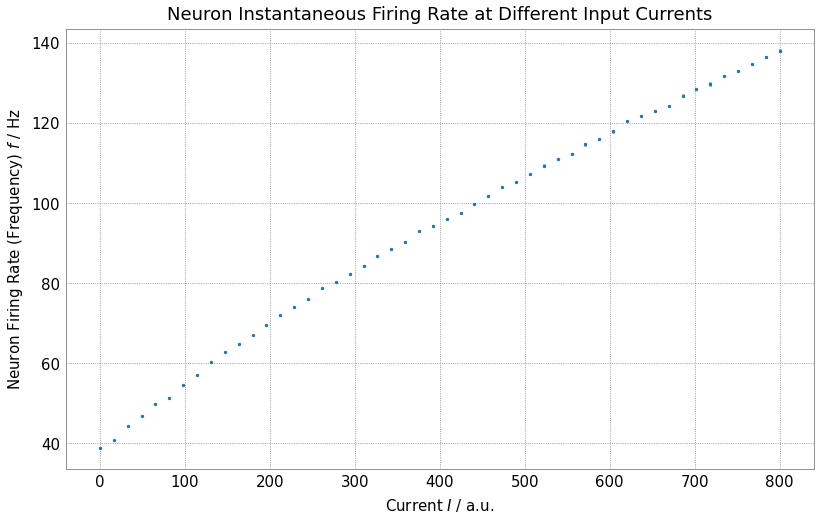

In [12]:
plt.errorbar(
    measurement_currents,
    measurement_frequencies,
    yerr = measurement_frequencies_error,
    linestyle = '',
    marker = '.',
    markersize = 2
)
plt.title('Neuron Instantaneous Firing Rate at Different Input Currents')
plt.ylabel('Neuron Firing Rate (Frequency) $f$ / Hz')
plt.xlabel('Current $I$ / a.u.')
plt.savefig(results_folder.joinpath(f'fp_task1_freq_vs_I_{time.strftime("%Y%m%d-%H%M%S")}.png'))
plt.show()

### Synaptic stimuli and PSP stacking

In the previous tasks, we analyzed the spiking dynamics of an isolated neuron.
In this task, we want to look at the membrane response of the neuron to stimulations of incoming spikes.
Your goal is to reproduce the image of PSP-Stacking (summation) from the introduction.
For this, you might find it helpful to look into pynn_introduction again.

A remark about the calibration loaded above:
While this calibration is not needed for the simple experiments above, it is essential when looking at synaptic inputs.
Therefore, you should load it when setting up this experiment using: `pynn.setup(initial_config=calib)`.

Steps:

- Set up a population of one neuron with the default neuron parameters to record its membrane potential.  
- Create a population of one SpikeSourceArray as a stimulating population.  
- Connect the stimulating population to the neuron population.  
- Find a suitable spike pattern to recreate the plot (you might require multiple spikes).  
- Can the neuron spike with the current neuron configuration?
  Explain.  
- Suggest and implement changes in the configuration so that the neuron spikes.
  Try to apply one change at a time.
  Explain your choices.  
- Can you tell which changes can be theoretically equivalent?  


*Hint*: Changes can be related to neuron parameters, projection, or population.

The neuron spiked 0 time(s).
The spike time(s) were: [] ms


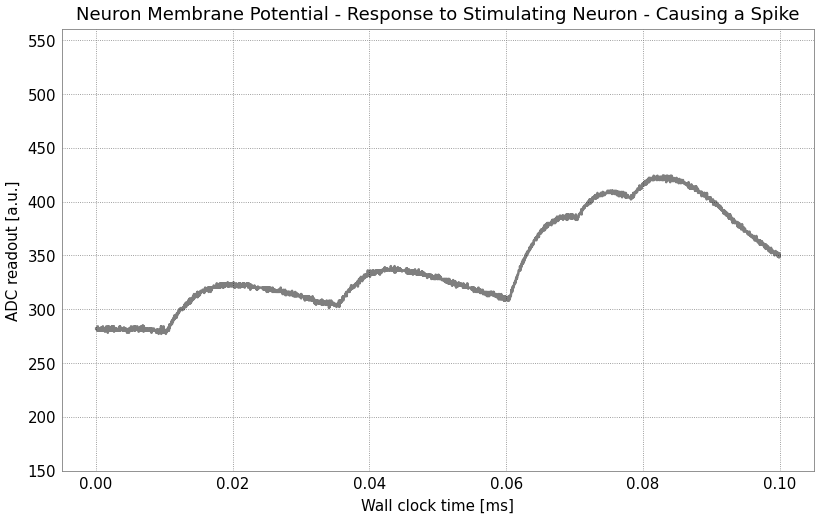

In [13]:
pynn.setup(initial_config=calib)

# define the neuron with default parameters
n_neurons = 1
neuron_type = pynn.cells.HXNeuron()

# set up the population of one neuron
pop = pynn.Population(n_neurons, neuron_type)
# record spikes and membrane potential 'v' of the neuron in the population
pop.record(["spikes", "v"])

# create a stimulating source population of 1
# choose spike times to cause a spike in the neuron in 'pop' (see graph below)
spike_times = [0.01, 0.035, 0.06, 0.06, 0.07, 0.078]
src = pynn.Population(1, pynn.cells.SpikeSourceArray(spike_times=spike_times))

# define a synapse and its weight
synapse_weight = 63
synapse = pynn.synapses.StaticSynapse(weight=synapse_weight)


# connect the pre-synaptic stimulating population 'src' to the post-synaptic neuron in 'pop'
pynn.Projection(src, pop, pynn.AllToAllConnector(),
                synapse_type=synapse, receptor_type="excitatory")

duration = 0.1    # ms
pynn.run(duration)

# read out the spikes of the neuron in 'pop'
spiketrain = pop.get_data("spikes").segments[0].spiketrains[0]
print(f"The neuron spiked {len(spiketrain)} time(s).")
print(f"The spike time(s) were: {spiketrain}")

# plot its membrane potential
plot_membrane_dynamics(pop, ylim=(150, 560))
plt.title('Neuron Membrane Potential - Response to Stimulating Neuron - Causing a Spike')
plt.savefig(results_folder.joinpath(f'fp_task1_PSP_stacking_{time.strftime("%Y%m%d-%H%M%S")}.png'))
plt.show()

While the general pattern of spikes can be copied, due to the different parameters of the observed neuron, such as its threshold potential, the absolute scale on the y-axis will be different. Still, it can be noted that the general shape is still achievable, although the stimulating spike times needed to be spaced out more in time to prevent a spike in the neuron too early.